# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np


In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')#completa el código
usage = pd.read_csv('/datasets/usage.csv')#completa el código

In [ ]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:

# cantidad de nulos para users
#utilizamos isnull para el conteo de valores nulos
print("Conteo de valores nulos:",users.isnull().sum().sum())
print("Proporciones de valores nulos por columna:")
print(users.isnull().mean())



Conteo de valores nulos: 4003
Proporciones de valores nulos por columna:
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para users
#utilizamos isna para el conteo de valores nulos
print("Conteo de valores nulos:",users.isna().sum().sum())
print("Proporciones de valores nulos por columna:")
print(users.isna().mean())


Conteo de valores nulos: 4003
Proporciones de valores nulos por columna:
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:

# cantidad de nulos para usage
#utilizamos isnull para el conteo de valores nulos
print("Conteo de valores nulos:",usage.isnull().sum().sum())
print("Proporciones de valores nulos por columna:")
print(usage.isnull().mean())



Conteo de valores nulos: 40022
Proporciones de valores nulos por columna:
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


In [ ]:
# cantidad de nulos para usage
#utilizamos isna para el conteo de valores nulos
print("Conteo de valores nulos:",usage.isna().sum().sum())
print("Proporciones de valores nulos por columna:")
print(usage.isna().mean())

Conteo de valores nulos: 40022
Proporciones de valores nulos por columna:
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

**Interpretación:**

- En el dataframe `users` eliminamos `churndate` ya que tiene un **88%** de valores faltantes.
- En el dataframe `users` deberíamos imputar `city` ya que tiene un **11%** de valores faltantes.
- En el dataframe `usage` valdr{ia la pena imputar o en dado caso ignorar los valores de  `date`,`duration` y `length` ya que tienen un porcentaje de valores faltantes igual a **0.12%, 55% y 44%** respectivamente. Es muy arriesgado hacer un análisis de casos completos, ya que el conteo total de valores faltantes supera el número de filas, lo que implica un riesgo importante de sesgar o perder gran parte de la información del dataframe.





### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000



- La columna `age` ya muestra de primera instancia la presencia de valores **centinelas**, ya que tiene muestra un valor mínimo de -999 (valor inválido); esto sesga todas las métricas posteriores, tal como la media, desviación, 25% quantil, 50% quantil, 75% quantil.

In [ ]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `duration` y `length` evalúan cosas diferentes, por lo que métricas como la media, std, min, max, 25%, 50%,75% no son comparables. Además, no se aprecian valores atípicos obvios en los valores mínimos o máximos. La única apreciación es la inconsistencia en los conteos, lo que puede sugerir una distribución de datos faltantes inconsistente entre duración y longitud. Es decir, registros para los que se tiene una duración, pero no una longitud o viceversa, o faltan las dos o no falta ninguna. Esto afecta directamente el conteo total de estos campos que deberían dar, si fueran completos, los 40000 registros del dataframe.

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
user_city_plan_stats=users[columnas_user].describe()
print("number of missing data in city:", 4000-user_city_plan_stats['city'][0])
print ("number of missing data in plan:", 4000-user_city_plan_stats['plan'][0])
user_city_plan_stats



number of missing data in city: 469
number of missing data in plan: 0


,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


- La columna `city` presenta 469 datos faltantes de acuerdo al número de registros esperados. Así mismo, muestra 7 valores únicos de ciudades, siendo *Bogotá* el de mayor frecuencia con un valor de 808 veces.
- La columna `plan` no presenta valores faltantes de acuerdo al número de registros esperados. Muestra solo 2 valores únicos, siendo *Básico* el de mayor frecuencia con un valor de 2595 veces.

In [ ]:
# explorar columna categórica de usage
usage_type_stats=usage['type'].describe()
print("number of missing data in type:", 40000-usage_type_stats[0])
usage_type_stats

number of missing data in type: 0


count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` no presenta datos faltantes de acuerdo al número de registros esperados. Así mismo, muestra 2 valores únicos, siendo *text* el de mayor frecuencia con un valor de 22092 veces.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**
Sobre el dataframe plans: Este conjunto de datos no se incluye en las presentes consideraciones debido a que su extensión es mínima (solo 2 filas) y la información se encuentra íntegramente completa.

Identificación de valores inválidos y centinelas: Se detectaron anomalías en las columnas city y age, principalmente mediante el uso de caracteres especiales como ? y valores centinela como -999. Asimismo, se recomienda convertir las columnas de tipo object a sus formatos correspondientes para asegurar una validación de datos robusta. Respecto a los valores faltantes, se identificaron nulos en el dataframe usage dentro de las columnas date (0.12%), duration (55%) y length (44%); mientras que en el dataframe users, las columnas afectadas son city (11%) y churndate (88%).

Acciones propuestas:

Imputación: Se sugiere sustituir el valor centinela -999 en la columna age por la edad mediana de la muestra.

Tratamiento de nulos: El valor ? en la columna city debe ser tratado como NA. Se desaconseja la imputación para evitar sesgos innecesarios o posibles conflictos legales derivados de la introducción de datos ficticios en los perfiles de los clientes.

Depuración: Se propone eliminar la columna churndate, dado que su alta tasa de valores faltantes (88%) la hace irrelevante para los fines de este análisis.

Preservación de datos: En las columnas date, duration y length, se optará por conservar los valores nulos. No existen variables auxiliares que permitan completar esta información de forma fiable y cualquier intento de imputación sesgaría la interpretación de la variable type y de la dimensión temporal del estudio.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'],errors="coerce")# completa el código

In [ ]:
#estadística descriptiva
users['reg_date'].describe()

count                    4000
unique                   3961
top       2026-05-10 00:00:00
freq                       40
first     2022-01-01 00:00:00
last      2026-05-10 00:00:00
Name: reg_date, dtype: object

In [ ]:
#Inspección rápida al principio
users['reg_date'].head(10)

0   2022-01-01 00:00:00.000000000
1   2022-01-01 06:34:17.914478619
2   2022-01-01 13:08:35.828957239
3   2022-01-01 19:42:53.743435858
4   2022-01-02 02:17:11.657914478
5   2022-01-02 08:51:29.572393098
6   2022-01-02 15:25:47.486871717
7   2022-01-02 22:00:05.401350337
8   2022-01-03 04:34:23.315828957
9   2022-01-03 11:08:41.230307576
Name: reg_date, dtype: datetime64[ns]

In [ ]:
#Inspección rápida al final
users['reg_date'].tail(10)

3990   2024-12-28 12:51:18.769692432
3991   2024-12-28 19:25:36.684171056
3992   2024-12-29 01:59:54.598649664
3993   2024-12-29 08:34:12.513128288
3994   2024-12-29 15:08:30.427606912
3995   2024-12-29 21:42:48.342085520
3996   2024-12-30 04:17:06.256564144
3997   2024-12-30 10:51:24.171042768
3998   2024-12-30 17:25:42.085521392
3999   2024-12-31 00:00:00.000000000
Name: reg_date, dtype: datetime64[ns]

In [ ]:
#Inspección rápida en medio
users['reg_date'].iloc[1990:2010]

1990   2023-06-29 21:34:09.812453112
1991   2023-06-30 04:08:27.726931736
1992   2023-06-30 10:42:45.641410352
1993   2023-06-30 17:17:03.555888976
1994   2023-06-30 23:51:21.470367592
1995   2023-07-01 06:25:39.384846216
1996   2023-07-01 12:59:57.299324832
1997   2023-07-01 19:34:15.213803456
1998   2023-07-02 02:08:33.128282072
1999   2023-07-02 08:42:51.042760696
2000   2023-07-02 15:17:08.957239312
2001   2023-07-02 21:51:26.871717936
2002   2023-07-03 04:25:44.786196552
2003   2023-07-03 11:00:02.700675168
2004   2023-07-03 17:34:20.615153792
2005   2023-07-04 00:08:38.529632408
2006   2023-07-04 06:42:56.444111032
2007   2023-07-04 13:17:14.358589648
2008   2023-07-04 19:51:32.273068272
2009   2023-07-05 02:25:50.187546888
Name: reg_date, dtype: datetime64[ns]

In [ ]:
#Indetificacion valores unicos y sus frecuencias de reg_date
print(users['reg_date'].dt.year.unique())
yearvalues=users['reg_date'].dt.year
users['reg_date'].groupby(by=yearvalues).count()


[2022 2026 2023 2024]


reg_date
2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

In [ ]:
#Visualización rápida de los registros con año 2026
users[users['reg_date'].dt.year == 2026].head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
40,10040,Ana,Garcia,59,Medellín,2026-05-10,Basico,NaN
56,10056,Luis,Garcia,29,CDMX,2026-05-10,Basico,"1,72187E+18"
60,10060,Carlos,Torres,45,CDMX,2026-05-10,Basico,NaN
70,10070,Mariana,Gomez,50,CDMX,2026-05-10,Premium,NaN
248,10248,Sofia,Garcia,20,Medellín,2026-05-10,Premium,"1,72506E+18"


In [ ]:
#Identificamos valores unicos del año 2026 (año inválido)
users[users['reg_date'].dt.year == 2026]['reg_date'].unique()

array(['2026-05-10T00:00:00.000000000'], dtype='datetime64[ns]')

En `reg_date` apreciamos que las fechas de registro de los usuarios van desde enero del 2022 hasta mayo del 2026. La principal inconsistencia está en el año 2026, ya que presenta 40 instancias con dos motivos de sospecha. La primera es la variable espacio-tiempo; los usuarios no pudieron registrarse en 2026 y tener actividad en 2024. La segunda variable son valores duplicados. Las 40 instancias de 2026 tienen el mismo valor en `users[reg_date]` lo cual es muy sospechoso porque son diferentes usuarios y muchos de ellos de diferentes ubicaciones.

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'],errors="coerce")# completa el código

In [ ]:
# Revisar los años presentes en `reg_date` de users
usage['date'].describe()


count                             39950
unique                            39950
top       2024-06-16 13:26:59.770494262
freq                                  1
first               2024-01-01 00:00:00
last                2024-06-30 00:00:00
Name: date, dtype: object

In [ ]:
#Inspección aleatoria arriba, en medio y al final para buscar incosistencias
print(usage['date'].head())
print(usage['date'].iloc[20000:20010])
print(usage['date'].tail())

0   2024-01-01 00:00:00.000000000
1   2024-01-01 00:06:30.969774244
2   2024-01-01 00:13:01.939548488
3   2024-01-01 00:19:32.909322733
4   2024-01-01 00:26:03.879096977
Name: date, dtype: datetime64[ns]
20000   2024-03-31 12:03:15.484887122
20001   2024-03-31 12:09:46.454661366
20002   2024-03-31 12:16:17.424435610
20003   2024-03-31 12:22:48.394209855
20004   2024-03-31 12:29:19.363984099
20005   2024-03-31 12:35:50.333758343
20006   2024-03-31 12:42:21.303532588
20007   2024-03-31 12:48:52.273306832
20008   2024-03-31 12:55:23.243081076
20009   2024-03-31 13:01:54.212855321
Name: date, dtype: datetime64[ns]
39995   2024-06-29 23:33:56.120903022
39996   2024-06-29 23:40:27.090677266
39997   2024-06-29 23:46:58.060451510
39998   2024-06-29 23:53:29.030225754
39999   2024-06-30 00:00:00.000000000
Name: date, dtype: datetime64[ns]


In [ ]:
#Conteo de registros y valores unicos de date
print(usage['date'].dt.year.unique())
values= usage['date'].dt.year
usage['date'].groupby(by=values).count()

[2024.   nan]


date
2024.0    39950
Name: date, dtype: int64

In [ ]:
#Evaluamos si los 50 faltantes para completar los registros totales son NA
usage['date'].isna().sum()

50

En `date` podemos ver consistencia en los datos. Las fechas corren desde enero del 2024 hasta junio del 2024. Donde se aprecia incluso la relevancia del tiempo en los registros de estas fechas para diferenciar incluso entre año-mes-día repetidos. Además, apreciamos que la suma del conteo de fechas registradas en 2024 + la suma de conteos de NA te da el conteo total del dataframe `usage`.  

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
  Los registros del año 2026 en `user[reg_date]` parecen ser muy sospechables y cuestionables para la relevancia de este análisis ya que el dataframe `usage` abarca principalmente el año 2024 por lo que los usuarios no pudieron registrase en 2026 y tener actividad en 2024 aun lado de que todos los valores del 2026 son valores duplicados con el siguinete valor `2026-05-10T00:00:00.000000000`.
- ¿Qué harías con ellas?
  Elimina a los usuarios con fecha de registro del 2026 (representa un error de registro) ya que no deberian tener un impacto en el dataframe `usage` abarcada principalmente en el año 2024. Evaluamos:

In [ ]:
#Evaluamos si encontramos usuarios con reg_date inválida en el datframe usage para evaluar
#impacto de trimming.
invalidUsers=users[users['reg_date'].dt.year==2026]['user_id'].unique()
usage[usage['user_id'].isin(invalidUsers)].count()

id          374
user_id     374
type        374
date        373
duration    157
length      217
dtype: int64

Como vemos eliminar a los usuarios si tiene un impacto ya que eliminaría 374 registros del dataframe `usage`. Esto correspondería aprox a un 0.9% de información. La cuestión sería si a la empresa le interesa retener esta información. Razón para eliminar posible indicación de datos ficticios, razón para retener solo hay un error de registo en la variable de `reg_date`. Esta estrategia implicaría convertir las fechas asociadas al año 2026 en NA y generar un impacto de 0.9% de información faltante en esta variable.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
#Un metodo muy interesante permite inferir el tipo de objetos de las columnas y
#tratar los valores nulos estandares como np.nan, None etc, como valores pd.NA
users=users.convert_dtypes()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     4000 non-null   Int64         
 1   first_name  4000 non-null   string        
 2   last_name   4000 non-null   string        
 3   age         4000 non-null   Int64         
 4   city        3531 non-null   string        
 5   reg_date    4000 non-null   datetime64[ns]
 6   plan        4000 non-null   string        
 7   churn_date  466 non-null    string        
dtypes: Int64(2), datetime64[ns](1), string(5)
memory usage: 257.9 KB


In [ ]:
usage=usage.convert_dtypes()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   id        40000 non-null  Int64         
 1   user_id   40000 non-null  Int64         
 2   type      40000 non-null  string        
 3   date      39950 non-null  datetime64[ns]
 4   duration  17924 non-null  Float64       
 5   length    22104 non-null  Int64         
dtypes: Float64(1), Int64(3), datetime64[ns](1), string(1)
memory usage: 2.0 MB


Parece que con fechas hay que trabajar `pd.to_datetime()` pero fuera de ahí el método reconoce bien las columnas y transforma eg. los `None` o `np.nan` a `pd.NA`. De igual forma, valdría la pena considerar remover la columna `churndate` con el 88% de missing data porque no es una columna que se use en análisis y satisface el criterio del 80-90% para considerar remover la columna.

In [ ]:
#procedo a remover la columna churndate del dataframe users
users=users.drop(columns=['churn_date'])
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     4000 non-null   Int64         
 1   first_name  4000 non-null   string        
 2   last_name   4000 non-null   string        
 3   age         4000 non-null   Int64         
 4   city        3531 non-null   string        
 5   reg_date    4000 non-null   datetime64[ns]
 6   plan        4000 non-null   string        
dtypes: Int64(2), datetime64[ns](1), string(4)
memory usage: 226.7 KB


In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999,age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users['city']=users['city'].replace('?',pd.NA)




# Verificar cambios
print(users['city'].describe())
print(users['city'].unique())


count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object
<StringArray>
['Medellín', <NA>, 'CDMX', 'Bogotá', 'GDL', 'MTY', 'Cali']
Length: 7, dtype: string


In [ ]:
# Marcar fechas futuras como NA para reg_date
users['reg_date'] = users['reg_date'].where(users['reg_date'].dt.year != 2026, pd.NA)

# Verificar cambios
print(users['reg_date'].describe())
print("nueva proporcion de valores nulos en reg_date:",users['reg_date'].isna().mean())



count                    3960
unique                   3960
top       1640995200000000000
freq                        1
Name: reg_date, dtype: int64
nueva proporcion de valores nulos en reg_date: 0.01


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby(by=['type'])['duration'].apply(lambda x: x.isna().mean())


type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [ ]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby(by=['type'])['length'].apply(lambda x: x.isna().mean())

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Basado en el método anterior, es evidente que `duration` y `length` son casos de missing data tipo MAR ya que los `pd.NA` de `duration` dependen del tipo `text` y los `pd.NA` de `length` dependen del tipo `call` con 99% de los datos faltantes en ambos casos.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Agrupar información por usuario
conteo_tipos = usage.groupby(['user_id', 'type']).size().unstack(fill_value=0)
promedio_length = usage.groupby('user_id')['length'].mean()
usage_agg = pd.concat([conteo_tipos, promedio_length], axis=1)
usage_agg=usage_agg.reset_index()


# observar resultado
usage_agg.head(3)

,user_id,call,text,length
0,10000,3,7,36.857143
1,10001,10,5,45.2
2,10002,2,5,45.0


In [ ]:
# Renombrar columnas
usage_agg=usage_agg.rename(columns={'call':'cant_llamadas','text':'cant_mensajes','length':'cant_minutos_llamada'})

# observar resultado
usage_agg.head(3)

,user_id,cant_llamadas,cant_mensajes,cant_minutos_llamada
0,10000,3,7,36.857143
1,10001,10,5,45.2
2,10002,2,5,45.0


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(3)

,user_id,first_name,last_name,age,city,reg_date,plan,cant_llamadas,cant_mensajes,cant_minutos_llamada
0,10000,Carlos,Garcia,38,Medellín,1640995200000000000,Basico,3.0,7.0,36.857143
1,10001,Mateo,Torres,53,<NA>,1641018857914478619,Basico,10.0,5.0,45.2
2,10002,Sofia,Ramirez,57,CDMX,1641042515828957239,Basico,2.0,5.0,45.0


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
user_profile[['age','cant_llamadas','cant_mensajes','cant_minutos_llamada']].describe()

,age,cant_llamadas,cant_mensajes,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3981.000000
mean,48.122250,4.478120,5.524381,52.249661
std,17.690408,2.144238,2.358416,28.914064
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,3.000000,4.000000,44.000000
50%,47.000000,4.000000,5.000000,50.333333
75%,63.000000,6.000000,7.000000,56.181818
max,79.000000,15.000000,17.000000,764.000000


In [ ]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True)


Basico     0.64875
Premium    0.35125
Name: plan, dtype: Float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

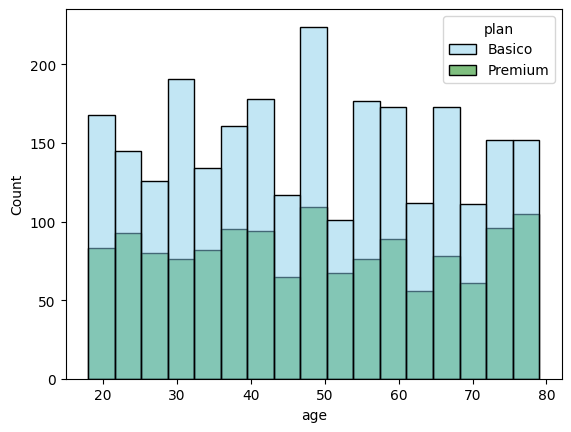

In [ ]:
# Histograma para visualizar la edad (age)


sns.histplot(user_profile,x='age',hue='plan',palette=['skyblue','green'])
plt.show()



💡Insights:
- Dominancia del Plan Básico: Se observa que el Plan Básico es el producto con mayor penetración de mercado de manera transversal. Esta tendencia está relacionada, presumiblemente, con su accesibilidad económica, posicionándolo como la opción de entrada para la mayoría de la población.

- Segmentos de Alto Valor (50 años): Los clientes en el rango de los 50 años representan el segmento de mayor valor estratégico (Core Segment). Este grupo no solo presenta el volumen de consumo más alto de la muestra, sino que también lidera la adopción de planes Premium, demostrando un equilibrio entre lealtad y capacidad de gasto.

- Comportamiento de la Población Joven (<30 años): Existe un interés temprano por los servicios Premium en los menores de 30 años. Sin embargo, se detecta un punto de inflexión al alcanzar la tercera década, donde el consumo se desplaza mayoritariamente hacia el Plan Básico, para luego iniciar una recuperación gradual de la preferencia Premium a partir de los 40 años.

- Fidelización en Adultos Mayores (>70 años): A partir de los 70 años, la preferencia por el Plan Premium se consolida de forma contundente. Este segmento muestra la inclinación más marcada hacia productos de alta gama dentro de la distribución total.

- Volatilidad en la Madurez (50-70 años): El rango comprendido entre los 50 y 70 años presenta fluctuaciones significativas en las preferencias; no obstante, al superar los 70 años, esta oscilación cesa en favor de una clara preferencia del consumo Premium.

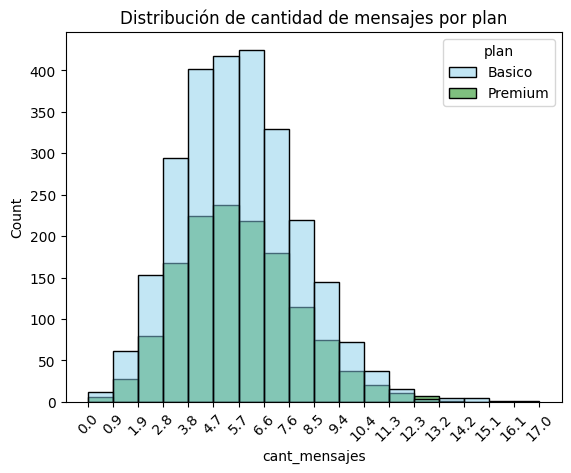

In [ ]:
# Histograma para visualizar la cant_mensajes
# 1. Calculamos los límites de los 18 bins
nbins=18
puntos_eje = np.linspace(user_profile['cant_mensajes'].min(),
                         user_profile['cant_mensajes'].max(),
                         nbins+1)

# 2. Graficamos
sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=puntos_eje    # Forzamos los bins a usar nuestros puntos
)

# 3. Ajustamos los ticks con rotación y redondeo para que sea legible
plt.xticks(puntos_eje, labels=np.round(puntos_eje, 1), rotation=45)

plt.title('Distribución de cantidad de mensajes por plan')
plt.show()



💡Insights:

- Morfología de la Distribución: La distribución presenta un sesgo a la derecha (asimetría positiva). El tipo de plan no parece alterar la forma de la distribución, afectando únicamente a las frecuencias observadas; esto se atribuye probablemente a la diferencia en el volumen de usuarios entre el plan Premium y el plan Basic.

- Tendencia Central (Moda): El valor con mayor frecuencia (moda) en la distribución se sitúa en un rango que oscila entre los 5.7 y 6.6 mensajes por usuario.

- Análisis de la Cola Derecha: Es necesario investigar el comportamiento de la cola derecha, específicamente la reducción en las frecuencias reportadas para usuarios con una cantidad de mensajes superior a 12.3(ejemplo). Se debe determinar si este fenómeno responde a limitaciones técnicas del plan, políticas de consumo tras superar límites establecidos, o simplemente a una baja densidad de usuarios con ese perfil de uso.

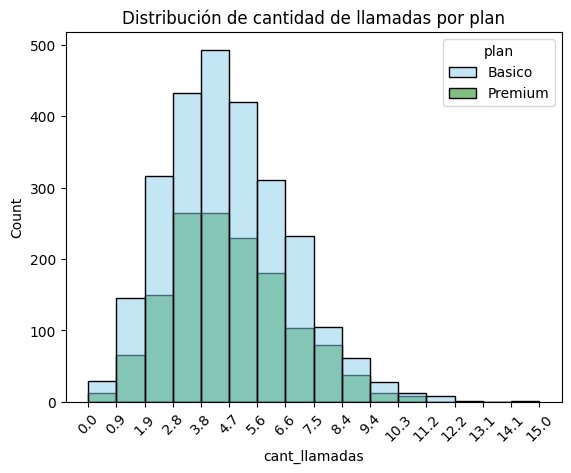

In [ ]:
# Histograma para visualizar la cant_llamadas
# 1. Calculamos los límites de los 16 bins

nbins=16
puntos_eje = np.linspace(user_profile['cant_llamadas'].min(),
                         user_profile['cant_llamadas'].max(),
                         nbins+1)

# 2. Graficamos
sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=puntos_eje    # Forzamos los bins a usar nuestros puntos
)

# 3. Ajustamos los ticks con rotación y redondeo para que sea legible
plt.xticks(puntos_eje, labels=np.round(puntos_eje, 1), rotation=45)

plt.title('Distribución de cantidad de llamadas por plan')
plt.show()



💡Insights:
- Morfología de la Distribución: La distribución presenta un sesgo a la derecha (asimetría positiva). El tipo de plan no parece alterar la forma de la distribución, afectando únicamente a las frecuencias observadas; esto se atribuye probablemente a la diferencia en el volumen de usuarios entre el plan Premium y el plan Basic.

- Tendencia Central (Moda): El valor con mayor frecuencia (moda) en la distribución se sitúa en un rango que oscila entre los 3.8 y 4.7 llamadas por usuario.

- Análisis de la Cola Derecha: Es necesario investigar el comportamiento de la cola derecha, específicamente la reducción en las frecuencias reportadas para usuarios con una cantidad de llamadas superior a 10.3 (ejemplo). Se debe determinar si este fenómeno responde a limitaciones técnicas del plan, políticas de consumo tras superar límites establecidos, o simplemente a una baja densidad de usuarios con ese perfil de uso.

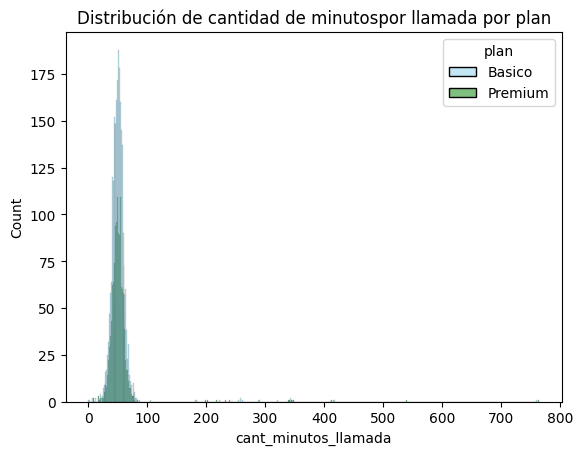

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
# 2. Graficamos
sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',
    palette=['skyblue', 'green'],
    bins='auto'
)


plt.title('Distribución de cantidad de minutospor llamada por plan')
plt.show()




💡Insights:


- Tendencia Central: La distribución de la duración de las llamadas muestra un comportamiento aparentemente normal, con una media aproximada de 50 minutos. Esta tendencia es consistente tanto para los usuarios del plan Premium como para los del plan Basic.

- Identificación de Anomalías: Se han detectado valores atípicos (outliers) en un rango que oscila entre los 200 y 800 minutos. Es necesario realizar una validación estadística adicional  para confirmar si estos puntos deben ser tratados o eliminados.

- Impacto del Plan: El tipo de suscripción no altera la forma funcional de la distribución. La diferencia visual en el gráfico se debe exclusivamente a las frecuencias, lo cual sugiere una disparidad en el tamaño de las muestras: una base de usuarios significativamente mayor en el plan Basic frente a una menor densidad en el plan Premium.



### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

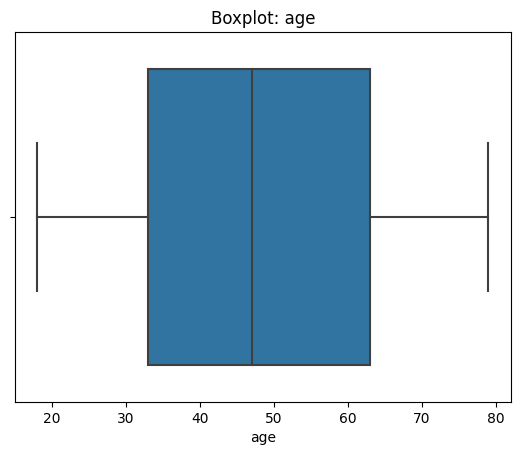

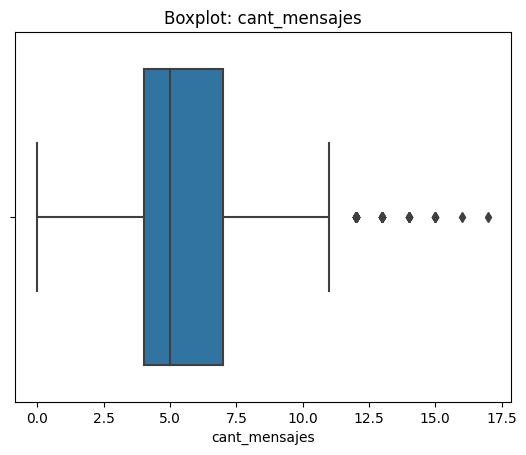

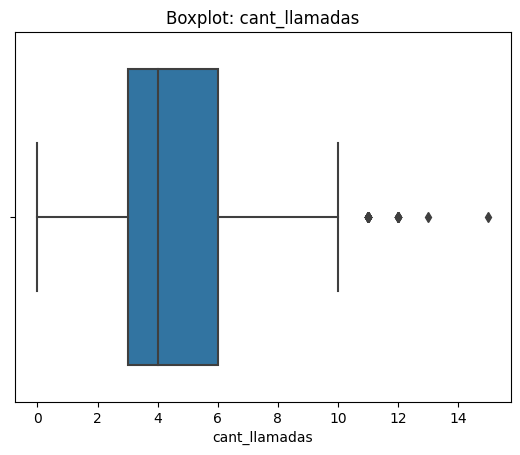

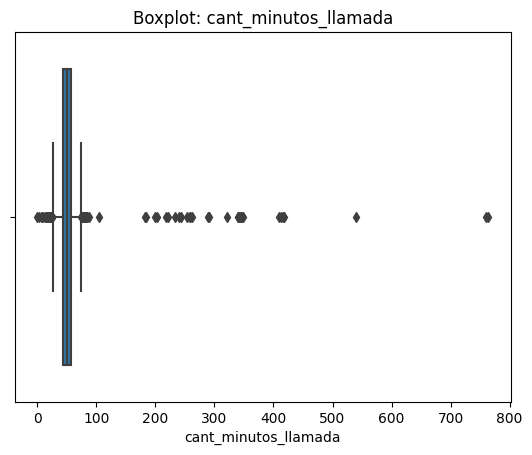

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data=user_profile,x=col)
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights:
- Age: ...(presenta o no outliers)
- cant_mensajes: ...
- cant_llamadas: ...
- cant_minutos_llamada: ...

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada'] #columnas con outliers
for col in columnas_limites:
    #Limite superior e inferior de cada variable con el metodo IQR
    IQR=user_profile[col].quantile(q=0.75)-user_profile[col].quantile(q=0.25)
    LS=user_profile[col].quantile(q=0.75)+(1.5*IQR)
    LI=user_profile[col].quantile(q=0.25)-(1.5*IQR)
    if LI<0: #Vamos a forzar valores validos para las columnas (valores negativos no son posibles)
        LI=0

    print (f'el limite superior de columna {col} es:',LS,f'el limite inferior de columna {col} es:',LI)



el limite superior de columna cant_mensajes es: 11.5 el limite inferior de columna cant_mensajes es: 0
el limite superior de columna cant_llamadas es: 10.5 el limite inferior de columna cant_llamadas es: 0
el limite superior de columna cant_minutos_llamada es: 74.45454545454545 el limite inferior de columna cant_minutos_llamada es: 25.72727272727273


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3981.000000
mean,5.524381,4.478120,52.249661
std,2.358416,2.144238,28.914064
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,44.000000
50%,5.000000,4.000000,50.333333
75%,7.000000,6.000000,56.181818
max,17.000000,15.000000,764.000000


💡Insights:

- cant_mensajes: mantener o no outliers, porqué?
- cant_llamadas: mantener o no outliers, porqué?
- cant_minutos_llamada: mantener o no outliers, porqué?



**Estrategia en el manejo de outliers del dataset:**
1. Cantidad de Mensajes y Cantidad de Llamadas (`cant_mensajes`, `cant_llamadas`)
Decisión: Conservar (Keeping).

Justificación: Se sugiere conservar los valores atípicos en estas variables ya que pueden reflejar un comportamiento real de los usuarios con respecto a su demanda de servicios. La variabilidad en el volumen de uso es plausible dentro de la naturaleza del consumo de telecomunicaciones, a pesar de alejarse estadísticamente de la media de la distribución.

2. Duración de Llamadas (`cant_minutos_llamada`)
Para esta variable se aplicará un criterio híbrido dependiendo del extremo de la distribución:


**Límite Superior (LS):**

Observación:
 Los valores que oscilan entre 200 y 800 minutos por llamada resultan poco realistas cuando se ponen en contexto. Son puntos sumamente alejados de la distribución típica.

Acción: Debido a que existe una cantidad considerable de estos puntos, se optaría por evaluar el efecto de un Capping (truncamiento al valor del límite superior) antes de proceder con un Trimming (eliminación total), para evitar la pérdida excesiva de datos. Se propone ajustar el criterio de validación para proteger la variabilidad natural del servicio; valores en el rango de 100 a 120 minutos se consideran comportamientos plausibles de consumo extendido y deben ser mantenidos (keeping). El tratamiento de valores atípicos se reservará exclusivamente para aquellos puntos que excedan este umbral de realismo, garantizando así que la limpieza no sacrifique datos con valor estadístico real.


**Límite Inferior (LI):**


Observación: Se han registrado valores por debajo del límite inferior, incluyendo llamadas de 0 minutos.

Acción: Mantenimiento (Keeping). Es técnicamente posible tener llamadas de muy corta duración (menos de 25 minutos). Los registros de 0 minutos pueden interpretarse como errores de conexión o intentos de llamada fallidos, fenómenos que son frecuentes en el servicio.




---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso


def classifyUso(df):
    # 1. Definimos las condiciones
    condiciones = [
        (df['cant_llamadas'] < 5) & (df['cant_mensajes'] < 5),
        (df['cant_llamadas'] < 10) & (df['cant_mensajes'] < 10)
    ]

    # 2. Definimos los resultados para cada condición
    resultados = ["Bajo Uso", "Medio Uso"]

    # 3. Aplicamos np.select(condiciones, resultados, default)
    df['grupo_uso'] = np.select(condiciones, resultados, default="Alto Uso")
    df['grupo_uso']=df['grupo_uso'].astype('string')

    return df
user_profile=classifyUso(user_profile)








In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,cant_llamadas,cant_mensajes,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,3.0,7.0,36.857143,Medio Uso,Adulto
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,10.0,5.0,45.2,Alto Uso,Adulto
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,2.0,5.0,45.0,Medio Uso,Adulto
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,3.0,11.0,48.181818,Alto Uso,Adulto Mayor
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,3.0,4.0,57.25,Bajo Uso,Adulto Mayor


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad

def classifyEdad(df):
    df_copy = df.copy()

    # 2. Convertimos a int estándar (de NumPy).
    # Transformamos el formato Int64 a int64 para compatibilidad con numpy
    df_copy['age'] = df_copy['age'].astype(int)
    # 1. Definimos las condiciones
    condiciones = [
        (df_copy['age'] < 30),
        (df_copy['age']>=30) & (df_copy['age'] < 60)
    ]

    # 2. Definimos los resultados para cada condición
    resultados = ["Joven", "Adulto"]

    # 3. Aplicamos np.select(condiciones, resultados, default)
    df_copy['grupo_edad'] = np.select(condiciones, resultados, default="Adulto Mayor")
    # 4. Formateamos
    df_copy['age'] = df_copy['age'].astype('Int64')
    df_copy['grupo_edad']=df_copy['grupo_edad'].astype("string")
    df_copy['reg_date'] = pd.to_datetime(df_copy['reg_date'],errors="coerce")
    return df_copy
user_profile=classifyEdad(user_profile)




In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,cant_llamadas,cant_mensajes,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,3.0,7.0,36.857143,Medio Uso,Adulto
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,10.0,5.0,45.2,Alto Uso,Adulto
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,2.0,5.0,45.0,Medio Uso,Adulto
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,3.0,11.0,48.181818,Alto Uso,Adulto Mayor
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,3.0,4.0,57.25,Bajo Uso,Adulto Mayor


In [ ]:
user_profile.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 4000 entries, 0 to 3999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   user_id               4000 non-null   Int64         
 1   first_name            4000 non-null   string        
 2   last_name             4000 non-null   string        
 3   age                   4000 non-null   Int64         
 4   city                  3435 non-null   string        
 5   reg_date              3960 non-null   datetime64[ns]
 6   plan                  4000 non-null   string        
 7   cant_llamadas         3999 non-null   float64       
 8   cant_mensajes         3999 non-null   float64       
 9   cant_minutos_llamada  3981 non-null   Float64       
 10  grupo_uso             4000 non-null   string        
 11  grupo_edad            4000 non-null   string        
dtypes: Float64(1), Int64(2), datetime64[ns](1), float64(2), string(6)
memory usa

### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

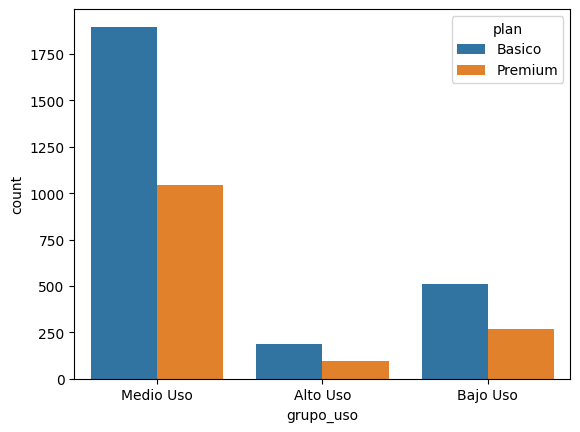

In [ ]:
# Visualización de los segmentos por uso


sns.countplot(data=user_profile,x='grupo_uso',hue='plan')

plt.show()



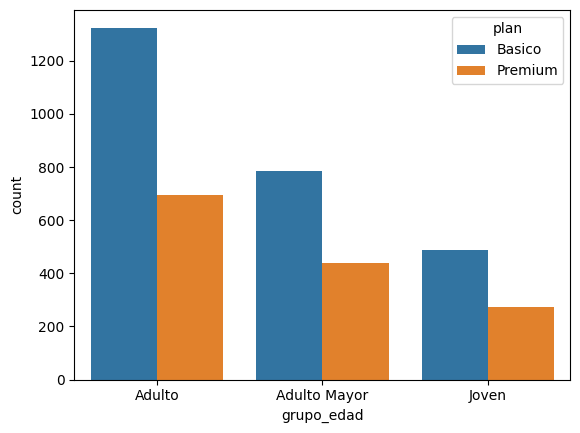

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile,x='grupo_edad',hue='plan')

plt.show()




---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
1. **Gestión de Valores Faltantes y Limpieza Estructural**
    - Dataframe `users`: Se eliminó la columna `churndate` debido a una carencia crítica de datos (88% de nulos) y su irrelevancia en este análisis. Así mismo, se desaconseja la imputación de city (11% de nulos) para evitar sesgos relacionados con el registro de perfiles.

    - Dataframe `usage`: Dada la alta incidencia de nulos en`duration` (55%) y `length` (44%), se determinó que son datos faltantes de tipo MAR (Missing At Random) dependientes de la variable `type`. Se descartó el análisis de casos completos para evitar la pérdida masiva de registros.

    - Inconcistencias temporales en `users[reg_date]` : Se identificaron registros anacrónicos en `reg_date` (10 de mayo del 2026) que presentan duplicidad exactamente 40 veces y contradicen la actividad registrada en 2024. Estos han sido tratados como valores nulos por su falta de fiabilidad técnica.

2. **Curación de Valores Inválidos**
    - Detección de Anomalías: Se localizaron valores centinela (-999) y caracteres especiales (?) en las variables de `city` y `age`.

    - Validación de columnas: Se recomendó la transición de columnas tipo object a sus formatos correspondientes. Entre las principales medidas encontramos la conversion de fechas a formato `datetime64` como la implementacion de la función `convert_dtypes()` para permitir el manejo y conversion directa de datos nulos en formato `pd.NA` para su debido manejo estructural; dentro de dichos formatos encontramos `Int64` y `Float64`. El dataframe final `user_profile` se compone de tipos `Int64`,`Float64`,`float64`,`string` y `datetime64` buscando así  asegurar una validación robusta.

3. **Estrategia de Manejo de Outliers (Valores Atípicos)**

    - Cantidad de mensajes y llamadas: Se decidió conservar la totalidad de los valores atípicos en `cant_mensajes` y `cant_llamadas`, ya que representan comportamientos de demanda reales en el sector de telecomunicaciones.

    - Duración de Llamadas (`cant_minutos_llamada`): Pueden presentar comportamientos plausibles si se mantienen registros de hasta 120 minutos como consumo extendido legítimo. Para valores extremos (200 a 800 min), se recomienda evaluar un truncamiento al límite superior en lugar de su eliminación, preservando el volumen de datos sin distorsionar la media. Para outliers respecto al límite inferior, se recomienda conservar los registros de 0 minutos, interpretados, por ejemplo, como intentos de llamada fallidos o errores de conexión inherentes al servicio.


🔍 **Segmentos por Edad**

- En general, el plan `basic` prevalece como dominante entre los tres segmentos: Jóvenes(menores de 30 años), Adultos (de 30 a 59 años) y Adultos Mayores (mayores de 60 años). Basado en la propuesta de segmentación, podemos observar que los Adultos son el sector dominante para dirigir campañas de consumo por parte de la empresa. Posteriormente, encontramos a los Adultos Mayores en segunda posición y, por último, a los Jóvenes. Probablemente, esta observación de consumo esté asociada a su capacidad adquisitiva o experiencia en los servicios de telecomunicaciones.


📊 **Segmentos por Nivel de Uso**

- En general, el plan `basic` prevalece como dominante entre los tres segmentos: Bajo(menos de 5 llamadas y mensajes), Medio (menos de 10 llamadas y mensajes, pero más que los perfiles Bajos) y Alto (son aquellos que tienen más de 10 llamadas y/o mensajes). Basado en la propuesta de segmentación, podemos observar que los perfiles Medios son el sector dominante para dirigir campañas de consumo por parte de la empresa. Posteriormente, encontramos a los perfiles en segunda posición y, por último, a los perfiles Altos. Probablemente, esta observación de consumo esté asociada a las necesidades predominantes de los clientes en cuanto al servicio de la empresa.



➡️ Esto sugiere que los clientes Adultos de 30 a 59 años, son el grupo objetivo para dirigir campañas de consumo, debido posiblemente a su mayor poder adquisitivo y demanda. Por otra parte, dichas campañas de consumos deben enfatizar los servicios con una demanda de uso Medio, es decir, campañas que consideren una demanda de llamadas y mensajes no superior a 10 y no menor a 5.


💡 **Recomendaciones**
Diseña campañas:
-  Vayan dirigidos a personas Mayores  (de 30 a 59 años)
Prioriza los planes:
- Que consideren una demanda de uso medio. Con una oferta de servicios de 10 llamadas y 10 mensajes anuales y distribuidas en las cuotas de consumo.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`